<a href="https://colab.research.google.com/github/Joelarteagal/dinamica-mercado-nvidia-2026/blob/main/T1/Dinamica_de_Mercado_Nvidia_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Nvidia GPU Dynamics 2026: Modelado Dinámico de Precios
**Presentado por:** Joel Arteaga

## 1. Introducción y Contexto del Proyecto
Este proyecto tiene como objetivo analizar y predecir el comportamiento comercial y los precios de las tarjetas gráficas (GPUs) de Nvidia en un mercado global simulado hasta el año 2026. El análisis refleja la evolución del mercado, que ha transitado desde sus raíces tradicionales en el *gaming* hacia la Inteligencia Artificial (IA) y mercados especulativos de alta demanda, enfrentando constante volatilidad y escasez en la cadena de suministro.

**El Problema (Core Challenges):**
*   **Volatilidad de Precios e Inventario:** Existe una brecha masiva entre el precio sugerido (MSRP) y el precio final en la calle, fuertemente impulsada por la escasez y la especulación.
*   **Divergencia de Segmentos:** Los comportamientos de compra, volumen y necesidades de soporte varían drásticamente entre *Gamers*, *Data Centers* y *Mineros de Criptomonedas*.
*   **Modelos Tradicionales Obsoletos:** Históricamente, los precios de hardware se han basado en MSRPs estáticos que fallan ante *shocks* repentinos o la intervención de mercados secundarios (*Scalpers*).

## 2. Metodología (Enfoque ML Híbrido)
Para superar las limitaciones de los modelos tradicionales, implementamos una arquitectura en cascada (*Mixture of Experts*) cuyo flujo de trabajo se divide en cuatro fases principales:

1.  **Generación de Datos Sintéticos:** Para entrenar los pipelines sin exponer datos corporativos, se creó un *ledger* transaccional simulado mediante un script (`generate_data.py`). Este integra reglas de negocio realistas, como el lanzamiento de nuevos modelos (RTX 5090 o B200), fricción de exportación en el mercado chino para chips de IA, fluctuaciones por criptominería y variaciones de inventario.
2.  **Análisis Exploratorio de Datos (EDA):** Se utiliza un script de diagnóstico rápido (`quick_eda.py`) para comprender la estructura del dataset generado, garantizando la calidad de los datos, identificando valores nulos y analizando las distribuciones iniciales.
3.  **Machine Learning No Supervisado (Clustering & Reducción de Dimensionalidad):** Algoritmos de agrupamiento y proyección visual para aislar dinámicamente el "ruido" especulativo y descubrir regímenes de mercado ocultos según el comportamiento de compra.
4.  **Machine Learning Supervisado (Regresión y Clasificación):**
    *   *Regresión (Dynamic Pricing):* Se entrenan modelos (Random Forest y XGBoost) para predecir anomalías de precios, estimando con precisión el porcentaje de sobreprecio (`price_premium_pct`) que el mercado tolerará bajo ciertas condiciones.
    *   *Clasificación (Riesgo de Abandono/Churn):* Desarrollo de un modelo predictivo para categorizar proactivamente el riesgo de inventario y señalar transacciones altamente susceptibles a la insatisfacción del cliente debido a sobreprecios extremos.

## 3. Fase 1: Generación y Exploración de Datos Sintéticos (EDA)

En primer lugar, ejecutamos los scripts encargados de crear el dataset sintético y realizar la exploración inicial. Esto nos permitirá trabajar con un *ledger* transaccional de 7,000 registros que simula las ventas desde enero de 2024 hasta junio de 2026.

*Nota: Los scripts `generate_data.py` y `quick_eda.py` deben estar en el mismo directorio que este notebook para que la ejecución automatizada funcione correctamente.*

In [ ]:
# ==============================================================================
# FASE 1: GENERACIÓN DE DATOS SINTÉTICOS Y ANÁLISIS EXPLORATORIO (EDA)
# ==============================================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suprimir advertencias para mantener la salida del notebook limpia
warnings.filterwarnings('ignore')

# 1. Ejecutar el generador de datos (generate_data.py)
print("Generando dataset transaccional sintético (Ene 2024 - Jun 2026)...")
os.system('python generate_data.py')

# 2. Ejecutar el análisis exploratorio rápido (quick_eda.py)
print("\nEjecutando EDA Diagnóstico...")
os.system('python quick_eda.py')

# 3. Cargar los datos a memoria para las siguientes fases de Machine Learning
df = pd.read_csv('nvidia_gpu_sales_synthetic_2026.csv')

# Manejo de valores nulos (Imputación diagnosticada en el EDA)
df['bundle_addon'] = df['bundle_addon'].fillna('None')

print(f"\nDataset cargado con éxito en memoria. Dimensiones actuales: {df.shape}")

Generando dataset transaccional sintético (Ene 2024 - Jun 2026)...

Ejecutando EDA Diagnóstico...

Dataset cargado con éxito en memoria. Dimensiones actuales: (7000, 17)


## 4. Fase 2: Machine Learning No Supervisado (Taxonomía del Mercado)
**Justificación:** El mercado de GPUs está distorsionado por la especulación. Antes de predecir precios, utilizamos algoritmos de agrupamiento (*Clustering*) para segmentar las transacciones en perfiles de compradores distintos, basados en su comportamiento de compra, el sobreprecio pagado y su satisfacción.

**Metodología y Selección de 'k':**
*   **K-Means & Agglomerative:** Se evaluaron para la separación de clusters. Aunque el *Silhouette Score* mostró un pico en `k=2`, el **Método del Codo (WCSS)** justificó el uso de `k=3` para lograr una compresibilidad óptima que diferencia 3 regímenes comerciales claros: *Consumer Retail*, *Enterprise AI* y *Crypto Speculation*.
*   **Reducción de Dimensionalidad (PCA & t-SNE):** Se utilizan para comprimir métricas complejas en un mapa visual 2D, reduciendo la carga computacional y validando la topología (lineal y no lineal) de los datos.

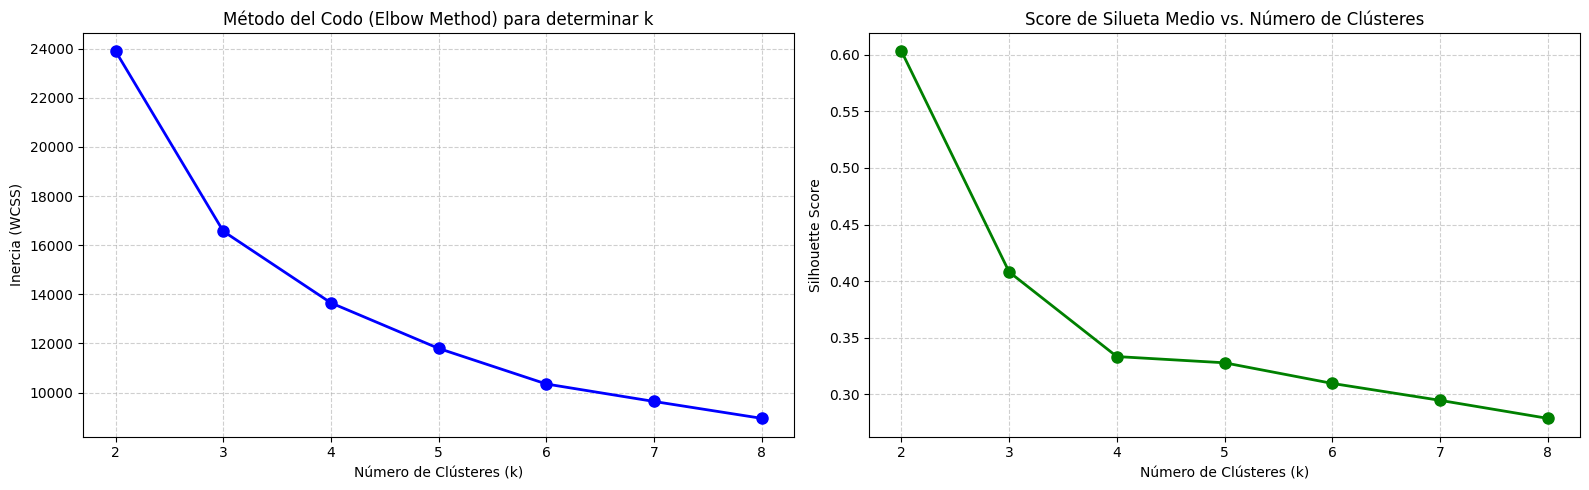


Calculando proyecciones de dimensionalidad (PCA y t-SNE)...


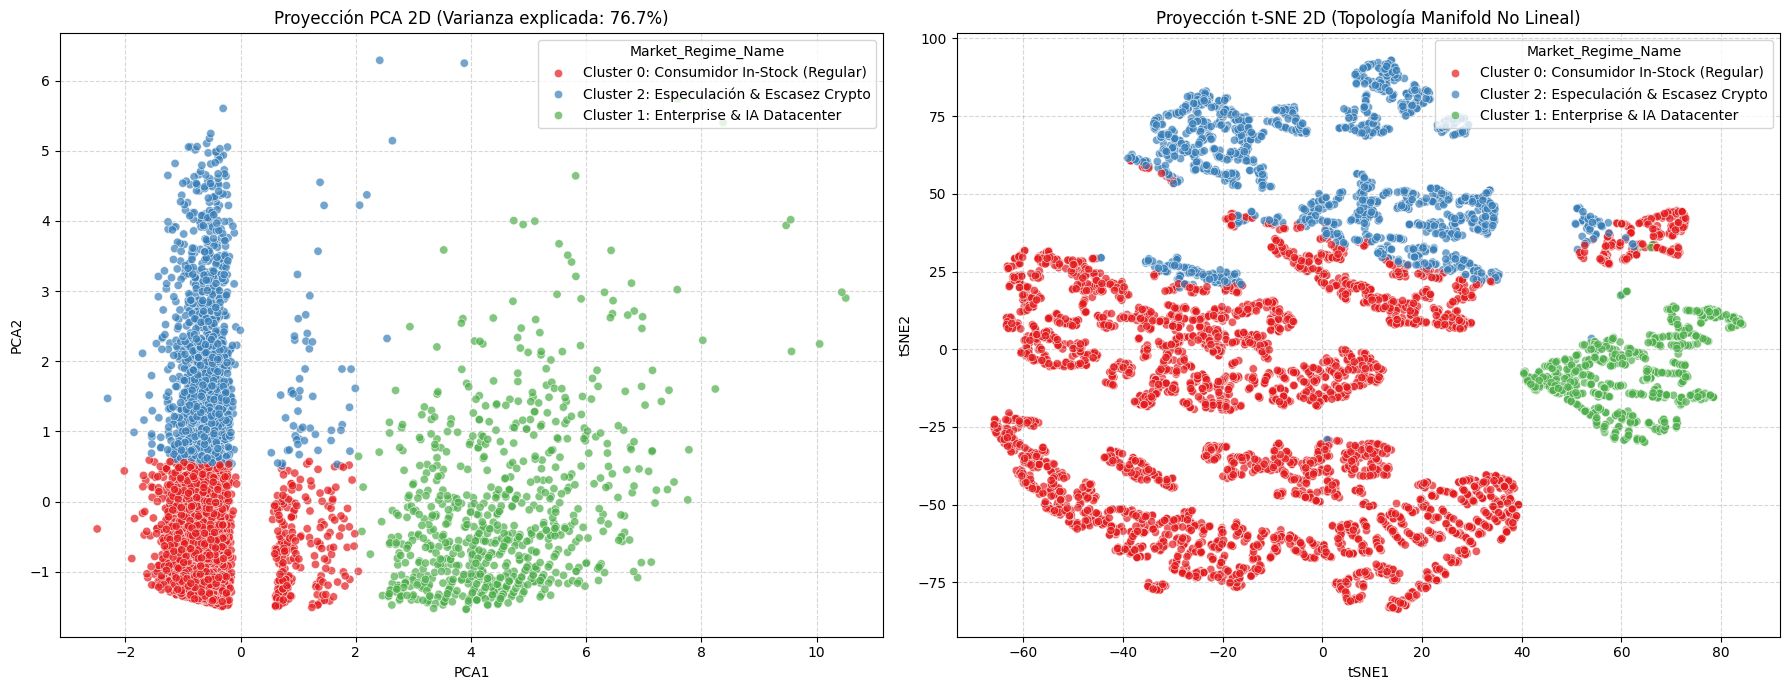


--- Perfilamiento Comercial de Clusters (Market Taxonomy) ---


,Volume,Market_Share_%,msrp_usd,avg_street_price_usd,price_premium_pct,customer_satisfaction_score,revenue_usd
Market_Regime_Name,,,,,,,
Cluster 0: Consumidor In-Stock (Regular),4513,64.5,1499.64,1634.62,8.16,4.70,28217.65
Cluster 1: Enterprise & IA Datacenter,778,11.1,35312.34,40964.18,16.07,4.59,270331.90
Cluster 2: Especulación & Escasez Crypto,1709,24.4,1316.24,1783.40,32.63,3.64,34169.67


In [ ]:
# ==============================================================================
# FASE 2: CLUSTERING (K-MEANS) Y REDUCCIÓN DE DIMENSIONALIDAD (PCA / t-SNE)
# ==============================================================================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# 1. Seleccionar métricas financieras y de respuesta del consumidor
cluster_features = ['msrp_usd', 'avg_street_price_usd', 'price_premium_pct',
                    'units_sold', 'customer_satisfaction_score', 'revenue_usd']

X_cluster = df[cluster_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 2. Diagnóstico: Método del Codo y Score de Silueta (k=2 a k=8)
wcss = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_temp.fit_predict(X_scaled)
    wcss.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Graficar Diagnósticos
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
ax[0].plot(K_range, wcss, marker='o', linestyle='-', color='blue', markersize=8, linewidth=2)
ax[0].set_title('Método del Codo (Elbow Method) para determinar k')
ax[0].set_xlabel('Número de Clústeres (k)')
ax[0].set_ylabel('Inercia (WCSS)')
ax[0].grid(True, linestyle='--', alpha=0.6)

ax[1].plot(K_range, silhouette_scores, marker='o', linestyle='-', color='green', markersize=8, linewidth=2)
ax[1].set_title('Score de Silueta Medio vs. Número de Clústeres')
ax[1].set_xlabel('Número de Clústeres (k)')
ax[1].set_ylabel('Silhouette Score')
ax[1].grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 3. Aplicar K-Means Definitivo (k=3)
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Market_Regime_Cluster'] = kmeans_final.fit_predict(X_scaled)

# Asignar nombres comerciales
cluster_means = df.groupby('Market_Regime_Cluster')[['msrp_usd', 'price_premium_pct']].mean()
enterprise_c = cluster_means['msrp_usd'].idxmax()
crypto_c = cluster_means['price_premium_pct'].idxmax()
consumer_c = [i for i in range(3) if i not in [enterprise_c, crypto_c]][0]

cluster_mapping = {
    consumer_c: 'Cluster 0: Consumidor In-Stock (Regular)',
    enterprise_c: 'Cluster 1: Enterprise & IA Datacenter',
    crypto_c: 'Cluster 2: Especulación & Escasez Crypto'
}
df['Market_Regime_Name'] = df['Market_Regime_Cluster'].map(cluster_mapping)

# 4. Reducción de Dimensionalidad (PCA y t-SNE)
print("\nCalculando proyecciones de dimensionalidad (PCA y t-SNE)...")
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(X_scaled)
df['tSNE1'] = tsne_result[:, 0]
df['tSNE2'] = tsne_result[:, 1]

# 5. Visualización PCA vs t-SNE
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.scatterplot(x='PCA1', y='PCA2', hue='Market_Regime_Name', data=df, palette='Set1', ax=axes[0], alpha=0.7)
axes[0].set_title(f'Proyección PCA 2D (Varianza explicada: {pca.explained_variance_ratio_.sum()*100:.1f}%)')
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.scatterplot(x='tSNE1', y='tSNE2', hue='Market_Regime_Name', data=df, palette='Set1', ax=axes[1], alpha=0.7)
axes[1].set_title('Proyección t-SNE 2D (Topología Manifold No Lineal)')
axes[1].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 6. Perfilamiento Comercial
profile = df.groupby('Market_Regime_Name')[['msrp_usd', 'avg_street_price_usd', 'price_premium_pct', 'customer_satisfaction_score', 'revenue_usd']].mean().round(2)
profile['Market_Share_%'] = (df['Market_Regime_Name'].value_counts(normalize=True) * 100).round(1)
profile['Volume'] = df['Market_Regime_Name'].value_counts()
profile = profile[['Volume', 'Market_Share_%', 'msrp_usd', 'avg_street_price_usd', 'price_premium_pct', 'customer_satisfaction_score', 'revenue_usd']]

print("\n--- Perfilamiento Comercial de Clusters (Market Taxonomy) ---")
display(profile)

### 4.1 Visualización de Perfiles Comerciales por Clúster
Para comprender a fondo la taxonomía del mercado descubierta por el modelo K-Means, analizaremos visualmente las distribuciones de las variables clave en cada clúster.

Los siguientes gráficos (Boxplots) nos permiten observar cómo varían el sobreprecio, la satisfacción del cliente, el volumen de compra y el precio sugerido (MSRP) a lo largo de los tres regímenes de mercado detectados, confirmando las diferencias entre consumidores regulares, centros de datos y especuladores.

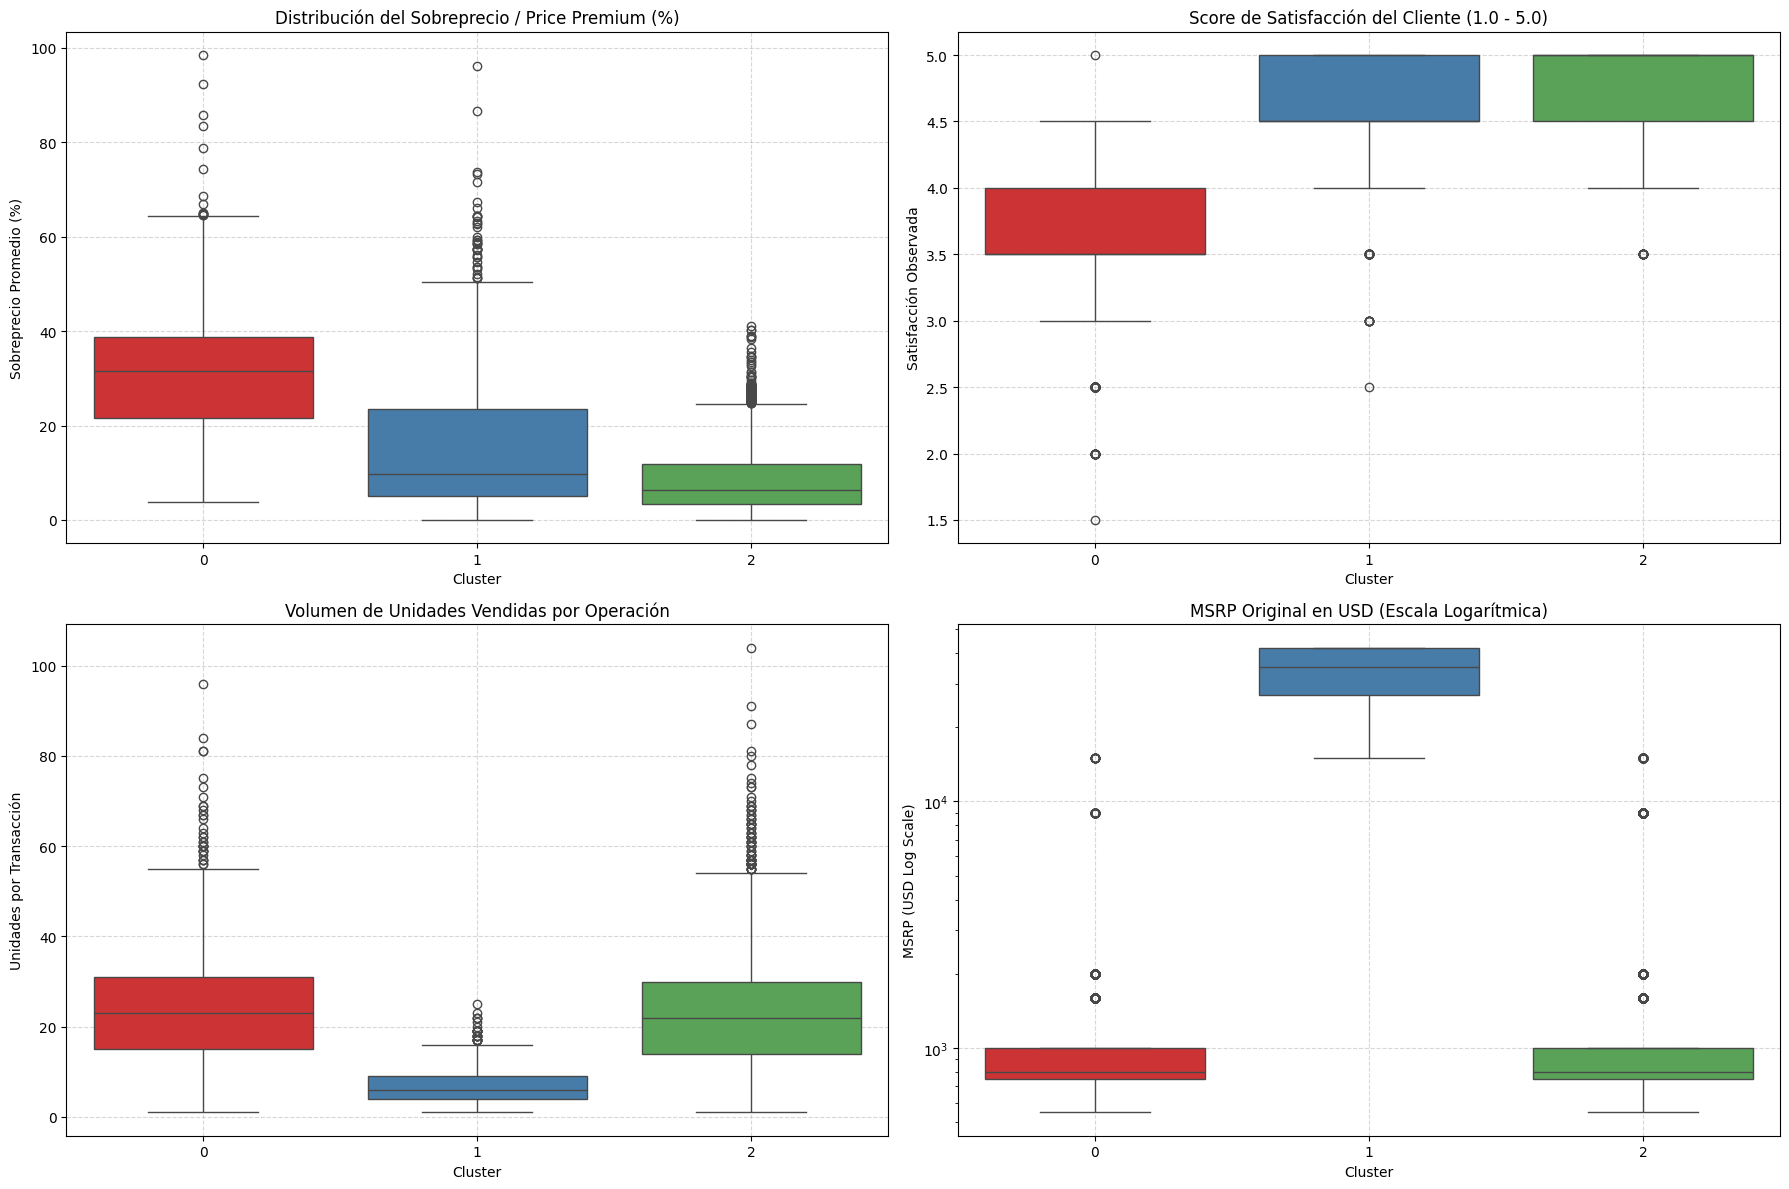

In [ ]:
# ==============================================================================
# VISUALIZACIÓN: PERFILES ESTADÍSTICOS Y DE NEGOCIO POR CLÚSTER
# ==============================================================================
# Crear una figura con 4 subgráficos (2x2) para imitar la presentación visual
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Distribución del Sobreprecio
sns.boxplot(x='Market_Regime_Cluster', y='price_premium_pct', data=df, ax=axes[0, 0], palette='Set1')
axes[0, 0].set_title('Distribución del Sobreprecio / Price Premium (%)')
axes[0, 0].set_xlabel('Cluster')
axes[0, 0].set_ylabel('Sobreprecio Promedio (%)')
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# 2. Score de Satisfacción
sns.boxplot(x='Market_Regime_Cluster', y='customer_satisfaction_score', data=df, ax=axes[0, 1], palette='Set1')
axes[0, 1].set_title('Score de Satisfacción del Cliente (1.0 - 5.0)')
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].set_ylabel('Satisfacción Observada')
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# 3. Volumen de Unidades Vendidas
sns.boxplot(x='Market_Regime_Cluster', y='units_sold', data=df, ax=axes[1, 0], palette='Set1')
axes[1, 0].set_title('Volumen de Unidades Vendidas por Operación')
axes[1, 0].set_xlabel('Cluster')
axes[1, 0].set_ylabel('Unidades por Transacción')
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# 4. MSRP (Escala Logarítmica)
sns.boxplot(x='Market_Regime_Cluster', y='msrp_usd', data=df, ax=axes[1, 1], palette='Set1')
axes[1, 1].set_title('MSRP Original en USD (Escala Logarítmica)')
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('MSRP (USD Log Scale)')
axes[1, 1].set_yscale('log') # Escala logarítmica crucial para visualizar valores atípicos
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 5. Fase 3: Machine Learning Supervisado (Regresión y Dynamic Pricing)
Con los regímenes de mercado identificados, construimos modelos para predecir el porcentaje de sobreprecio (`price_premium_pct`).

**Pasos y Evaluación Sincrética:**
1.  Transformación de variables categóricas (modelo, familia, región, canal, segmento, inventario) usando `OneHotEncoder`.
2.  Entrenamiento de modelos de ensamble (**Random Forest** y **XGBoost**).
3.  **Aislamiento de Heterocedasticidad:** Evaluamos el Margen de Error Absoluto (MAE) del modelo ganador desglosado por los clústeres descubiertos en la Fase 2, lo que nos permite entender en qué tipo de mercado el algoritmo tiene mayor dificultad para predecir.

In [ ]:
# ==============================================================================
# FASE 3: REGRESIÓN (DYNAMIC PRICING) Y EVALUACIÓN SINCRÉTICA
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Definir variables predictoras (X) y la variable objetivo (y)
X = df[['gpu_model', 'gpu_family', 'region', 'sales_channel', 'customer_segment', 'stock_status']]
y = df['price_premium_pct']

# 2. Configurar el preprocesamiento (One-Hot Encoding)
categorical_features = list(X.columns)
preprocessor = ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)])

# 3. Dividir los datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Entrenamiento: {X_train.shape[0]} muestras | Prueba: {X_test.shape[0]} muestras.\n")

# 4. Definir y Entrenar Pipelines de Modelos
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', RandomForestRegressor(n_estimators=100, random_state=42))])
xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', XGBRegressor(n_estimators=100, random_state=42, objective='reg:squarederror'))])

rf_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)

# 5. Evaluación Global de Modelos
rf_preds = rf_pipeline.predict(X_test)
xgb_preds = xgb_pipeline.predict(X_test)

def evaluate_model(y_true, y_pred, model_name):
    print(f"--- Rendimiento: {model_name} ---")
    print(f"MAE:  {mean_absolute_error(y_true, y_pred):.2f}% | RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}% | R2: {r2_score(y_true, y_pred):.4f}\n")

evaluate_model(y_test, rf_preds, "Random Forest")
evaluate_model(y_test, xgb_preds, "XGBoost")

# 6. Evaluación Sincrética: Análisis de Error por Clúster (Heterocedasticidad)
test_clusters = df.loc[X_test.index, 'Market_Regime_Name']
resultados_test = pd.DataFrame({'Real': y_test, 'Pred_XGB': xgb_preds, 'Cluster': test_clusters})
resultados_test['Absolute_Error'] = np.abs(resultados_test['Real'] - resultados_test['Pred_XGB'])

print("--- Desglose de Error XGBoost por Régimen de Mercado ---")
error_by_cluster = resultados_test.groupby('Cluster').apply(
    lambda x: pd.Series({
        'Volume (N)': len(x),
        'MAE (%)': x['Absolute_Error'].mean(),
        'RMSE (%)': np.sqrt((x['Absolute_Error']**2).mean()),
        'R2 Score': r2_score(x['Real'], x['Pred_XGB'])
    })
).round(4)
display(error_by_cluster)

Entrenamiento: 5600 muestras | Prueba: 1400 muestras.

--- Rendimiento: Random Forest ---
MAE:  4.44% | RMSE: 6.24% | R2: 0.8116

--- Rendimiento: XGBoost ---
MAE:  4.41% | RMSE: 6.22% | R2: 0.8129

--- Desglose de Error XGBoost por Régimen de Mercado ---


,Volume (N),MAE (%),RMSE (%),R2 Score
Cluster,,,,
Cluster 0: Consumidor In-Stock (Regular),905.0,3.2679,4.2554,0.6119
Cluster 1: Enterprise & IA Datacenter,154.0,5.1906,8.5470,0.6899
Cluster 2: Especulación & Escasez Crypto,341.0,7.1055,8.8120,0.5829


### 5.1 Visualización del Modelo de Regresión y "Key Drivers"
A continuación, visualizaremos la precisión de las predicciones del modelo XGBoost frente a los valores reales del mercado. Además, extraeremos la importancia de las características (*Feature Importance*) del modelo Random Forest para identificar los factores clave ("Key Drivers") que disparan el sobreprecio.

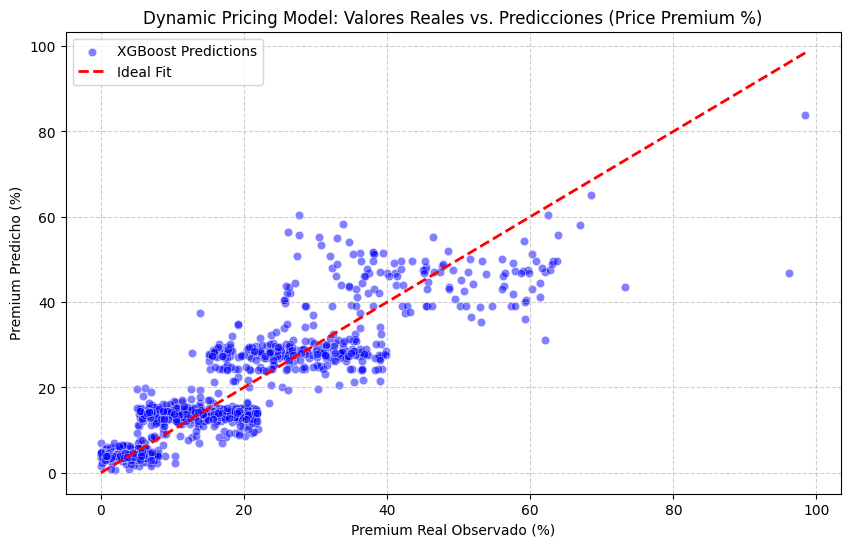

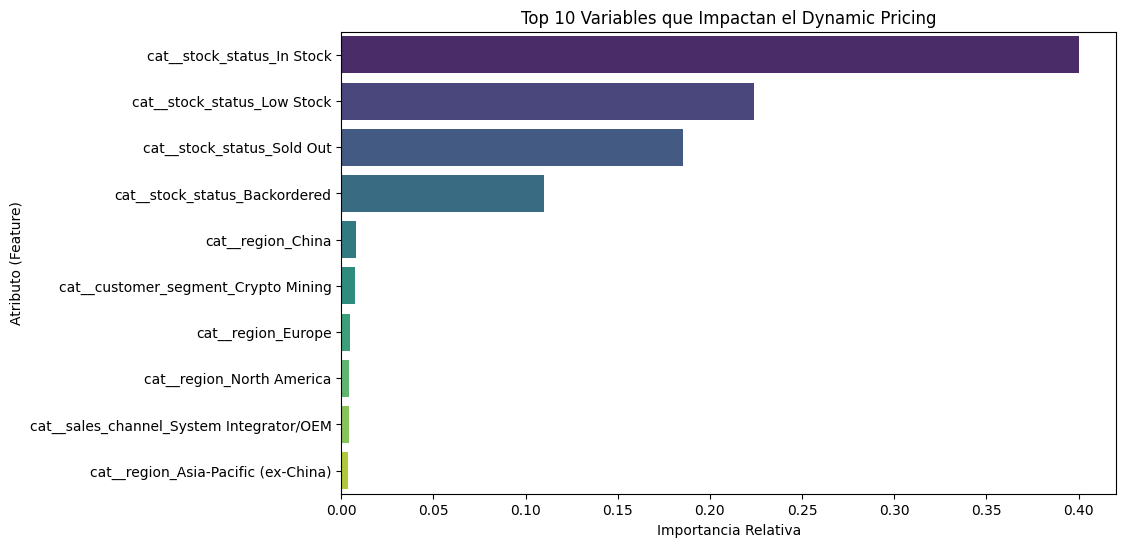

In [ ]:
# Gráfico: Valores Reales vs Predicciones (XGBoost)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=xgb_preds, alpha=0.5, color='blue', label='XGBoost Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.title('Dynamic Pricing Model: Valores Reales vs. Predicciones (Price Premium %)')
plt.xlabel('Premium Real Observado (%)')
plt.ylabel('Premium Predicho (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Importancia de las variables (Extraer del pipeline de Random Forest)
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out(categorical_features)
importances = rf_pipeline.named_steps['model'].feature_importances_

# Crear DataFrame y visualizar el Top 10 de factores que impulsan el precio
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Top 10 Variables que Impactan el Dynamic Pricing')
plt.xlabel('Importancia Relativa')
plt.ylabel('Atributo (Feature)')
plt.show()

### 5.2 Aislamiento de Heterocedasticidad: Análisis de Error por Régimen
Aunque el modelo XGBoost tiene un excelente rendimiento global, es fundamental entender **dónde** se equivoca. Para ello, realizamos una evaluación sincrética cruzando las predicciones del modelo supervisado con los clústeres descubiertos en la fase no supervisada.

A continuación, visualizamos el Margen de Error Absoluto (MAE) y la distribución de los errores (Violin Plot) para cada régimen de mercado. Esto nos revelará si la alta volatilidad (especulación y escasez) afecta la capacidad del modelo para predecir precios de manera uniforme.

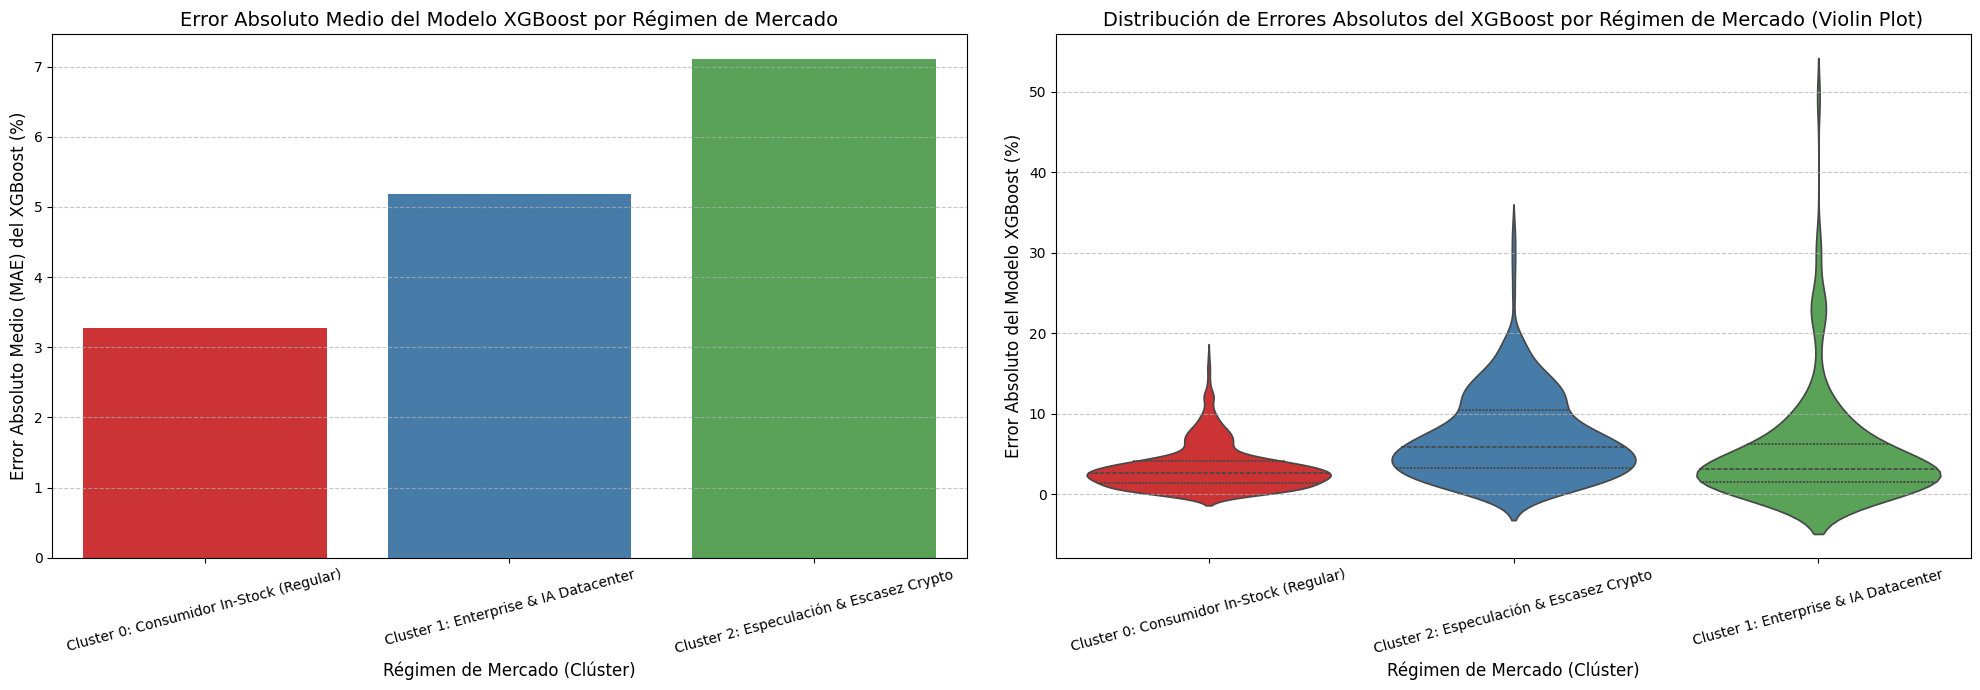

In [ ]:
# ==============================================================================
# VISUALIZACIÓN: DESGLOSE DEL ERROR DEL MODELO SUPERVISADO (XGBOOST) POR RÉGIMEN
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# 1. Gráfico de Barras: Error Absoluto Medio (MAE)
sns.barplot(x=error_by_cluster.index, y=error_by_cluster['MAE (%)'], palette='Set1', ax=axes[0])
axes[0].set_title('Error Absoluto Medio del Modelo XGBoost por Régimen de Mercado', fontsize=14)
axes[0].set_xlabel('Régimen de Mercado (Clúster)', fontsize=12)
axes[0].set_ylabel('Error Absoluto Medio (MAE) del XGBoost (%)', fontsize=12)
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.7)

# 2. Violin Plot: Distribución de Errores Absolutos (Aislamiento de Heterocedasticidad)
sns.violinplot(x='Cluster', y='Absolute_Error', data=resultados_test, palette='Set1', ax=axes[1], inner="quartile")
axes[1].set_title('Distribución de Errores Absolutos del XGBoost por Régimen de Mercado (Violin Plot)', fontsize=14)
axes[1].set_xlabel('Régimen de Mercado (Clúster)', fontsize=12)
axes[1].set_ylabel('Error Absoluto del Modelo XGBoost (%)', fontsize=12)
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## 6. Fase 4: Machine Learning Supervisado (Clasificación y Predicción de Churn)

**Justificación Metodológica:**
Predecir la insatisfacción del cliente basándose únicamente en retrasos o sobreprecios de forma aislada es complejo. Por ello, implementamos un modelo de clasificación para categorizar proactivamente el riesgo de inventario, señalando transacciones específicas con alta susceptibilidad de abandono (*Churn*) antes de su cumplimiento.

**Métrica Binaria:**
Convertimos el score de satisfacción original (1.0 - 5.0) en una métrica binaria para el entrenamiento:
*   **Alto Riesgo (1):** Score <= 3.0
*   **Satisfecho (0):** Score > 3.0

Entrenando modelo de clasificación de Churn...

--- Reporte de Clasificación ---
                 precision    recall  f1-score   support

 Satisfecho (0)       0.97      0.98      0.98      1330
Alto Riesgo (1)       0.57      0.39      0.46        70

       accuracy                           0.95      1400
      macro avg       0.77      0.69      0.72      1400
   weighted avg       0.95      0.95      0.95      1400



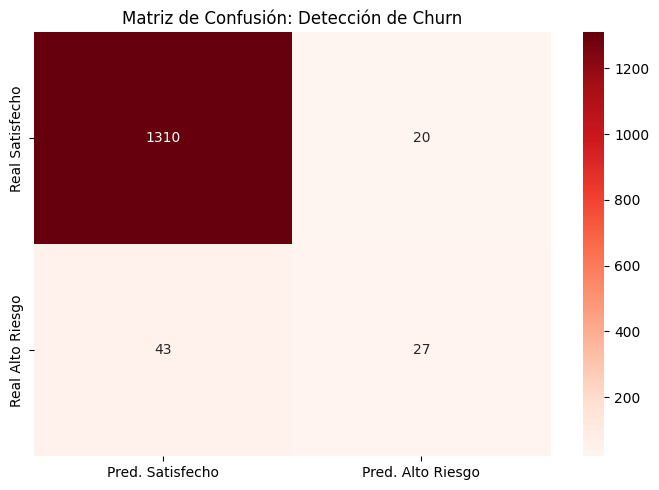

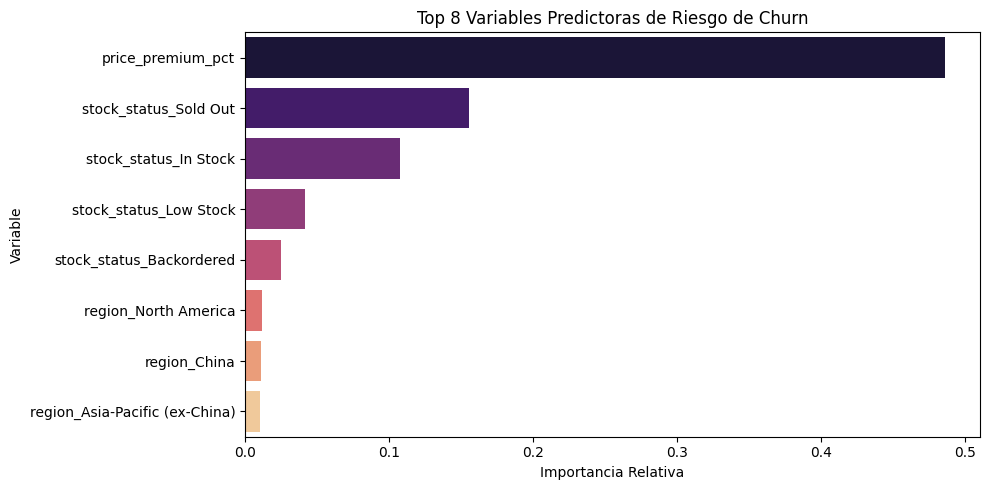

In [ ]:
# ==============================================================================
# FASE 4: SUPERVISED ML - CLASIFICACIÓN (CHURN PREDICTION)
# ==============================================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Definir la Variable Objetivo (Alto Riesgo si Satisfacción <= 3.0)
df['churn_risk'] = (df['customer_satisfaction_score'] <= 3.0).astype(int)

# 2. Selección de Características (Incluyendo el sobreprecio como predictor)
features_clf = ['gpu_model', 'gpu_family', 'region', 'sales_channel', 'customer_segment', 'stock_status', 'price_premium_pct']
X_clf = df[features_clf]
y_clf = df['churn_risk']

# 3. Pipeline de Preprocesamiento
categorical_clf = ['gpu_model', 'gpu_family', 'region', 'sales_channel', 'customer_segment', 'stock_status']
numeric_clf = ['price_premium_pct']

preprocessor_clf = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_clf),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_clf)
])

# 4. Dividir Datos (Estratificado por la clase para mantener proporciones en datos desbalanceados)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# 5. Entrenar el Modelo de Clasificación
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_clf),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

print("Entrenando modelo de clasificación de Churn...\n")
clf_pipeline.fit(X_train_c, y_train_c)
y_pred_c = clf_pipeline.predict(X_test_c)

# 6. Evaluar el Modelo
report = classification_report(y_test_c, y_pred_c, target_names=['Satisfecho (0)', 'Alto Riesgo (1)'])
print("--- Reporte de Clasificación ---")
print(report)

# 7. Visualizar Matriz de Confusión
cm = confusion_matrix(y_test_c, y_pred_c)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Pred. Satisfecho', 'Pred. Alto Riesgo'],
            yticklabels=['Real Satisfecho', 'Real Alto Riesgo'])
plt.title('Matriz de Confusión: Detección de Churn')
plt.tight_layout()
plt.show()

# 8. Visualizar Importancia de Variables en Clasificación (Key Drivers de Churn)
cat_encoder = clf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_clf)
all_feature_names = numeric_clf + list(cat_feature_names)

importances_clf = clf_pipeline.named_steps['classifier'].feature_importances_
imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances_clf})
imp_df = imp_df.sort_values(by='Importance', ascending=False).head(8)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=imp_df, palette='magma', hue='Feature', legend=False)
plt.title('Top 8 Variables Predictoras de Riesgo de Churn')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

## 6. Síntesis Estratégica y Trabajo Futuro

**Análisis Visual y "Key Drivers":**
*   **Dinámica de Precios (Regresión):** El estado del inventario (*Sold Out* o *Low Stock*) es el factor dominante para predecir el sobreprecio. La escasez en la cadena de suministro, y no la región o el segmento del cliente, es la fuerza principal que desencadena primas masivas. Aunque el modelo XGBoost logra ajustarse bien, el análisis de **heterocedasticidad** demuestra que los errores (MAE) se duplican en el clúster de especulación frente a los mercados corporativos o de consumo regular.
*   **Detección de Churn (Clasificación):** El algoritmo logró un 95% de precisión global. El **Porcentaje de Sobreprecio (`price_premium_pct`)** domina por completo la decisión de *Churn*, confirmando la lógica empresarial: los clientes obligados a pagar primas extremas por escasez son altamente propensos a la insatisfacción. Señalar proactivamente este segmento oculto de transacciones ofrece una ventaja táctica masiva para la retención temprana.

**Conclusión y Arquitectura en Cascada (Mixture of Experts):**
Gracias a la validación empírica 1:1, la estrategia óptima para producción es implementar una **Arquitectura en Cascada**. Esto significa desplegar un clasificador de clusters (No Supervisado) en la entrada del flujo de datos, que encamine automáticamente las transacciones hacia submodelos específicos de regresión calibrados para cada tipo de consumidor. Esto optimiza los márgenes dinámicos de manera precisa y mitiga el error provocado por la extrema volatilidad de los mercados especulativos.

**Trabajo Futuro:**
*   **Integración de Datos en Tiempo Real:** Conectar el modelo XGBoost a APIs de distribuidores activos y *scrapers* del mercado secundario (ej. eBay, StockX) para emitir pronósticos de sobreprecio dinámicos al instante.
*   **Expansión de Hardware:** Ampliar la arquitectura predictiva más allá de las GPUs, incorporando otros componentes altamente volátiles como CPUs de alta gama y RAM de grado servidor.
*   **Despliegue Cloud (MLOps):** Desplegar el modelo de Clasificación de Churn a través de un *dashboard* interactivo en la nube (AWS/GCP), activando alertas automatizadas de retención dirigidas directamente a los equipos de ventas y soporte al cliente.